In [17]:
import numpy as np
import time
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

In [4]:
#Zad 1,2
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
class_names = wine.target_names

print("\nWymiary danych:", X.shape[0], "próbek ×", X.shape[1], "cech")
print("\nNazwy cech:")
for i, f in enumerate(feature_names, start=1):
    print(f"{i:>2}. {f}")

print("\nRozkład klas:")
unique, counts = np.unique(y, return_counts=True)
for k, c in zip(unique, counts):
    print(f"Klasa {k} ({class_names[k]}): {c} próbek")

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

print("\nStandaryzacja wykonana (z-score): każda cecha ma średnią ~0 i odchylenie ~1.")
print("Dlaczego to konieczne przed PCA?")
print("- PCA jest wrażliwe na skalę zmiennych: cechy o dużej wariancji dominują analizę.")
print("- Standaryzacja wyrównuje wpływ cech mierzonych w różnych jednostkach/skalach.")


Wymiary danych: 178 próbek × 13 cech

Nazwy cech:
 1. alcohol
 2. malic_acid
 3. ash
 4. alcalinity_of_ash
 5. magnesium
 6. total_phenols
 7. flavanoids
 8. nonflavanoid_phenols
 9. proanthocyanins
10. color_intensity
11. hue
12. od280/od315_of_diluted_wines
13. proline

Rozkład klas:
Klasa 0 (class_0): 59 próbek
Klasa 1 (class_1): 71 próbek
Klasa 2 (class_2): 48 próbek

Standaryzacja wykonana (z-score): każda cecha ma średnią ~0 i odchylenie ~1.
Dlaczego to konieczne przed PCA?
- PCA jest wrażliwe na skalę zmiennych: cechy o dużej wariancji dominują analizę.
- Standaryzacja wyrównuje wpływ cech mierzonych w różnych jednostkach/skalach.


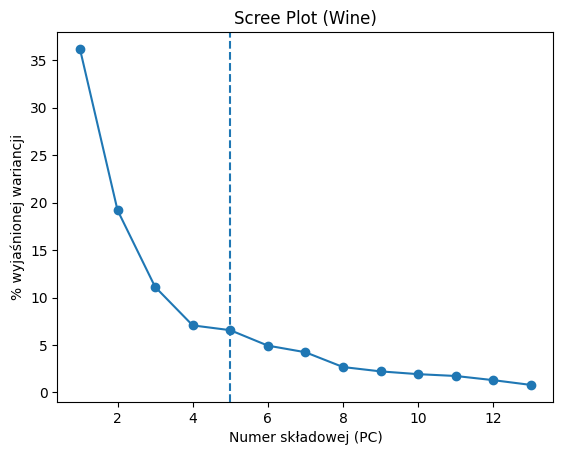


[Info] Próg 80% osiągnięty dla k=5 (skumulowana=80.2%).


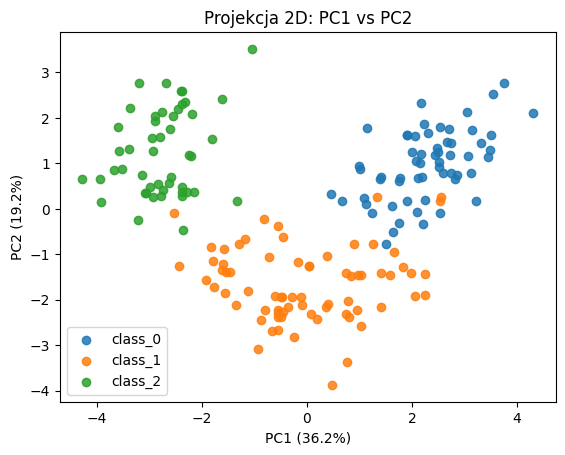

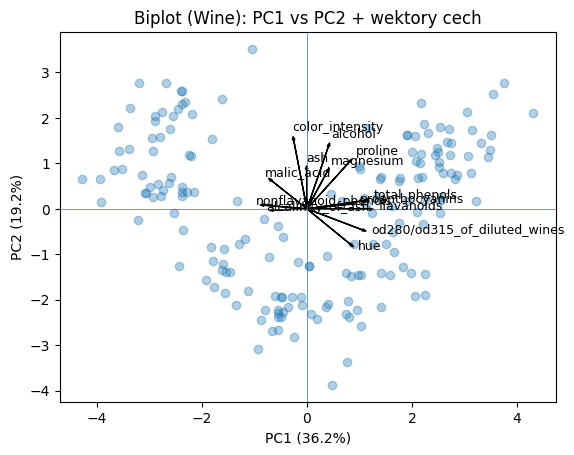

ŁADUNKI (LOADINGS) dla PC1 i PC2:


,PC1_loading,PC2_loading
alcohol,0.144329,0.483652
malic_acid,-0.245188,0.224931
ash,-0.002051,0.316069
alcalinity_of_ash,-0.239320,-0.010591
magnesium,0.141992,0.299634
total_phenols,0.394661,0.065040
flavanoids,0.422934,-0.003360
nonflavanoid_phenols,-0.298533,0.028779
proanthocyanins,0.313429,0.039302
color_intensity,-0.088617,0.529996


In [12]:
#Zad 3
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
class_names = wine.target_names

X_std = StandardScaler().fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_std)

evr = pca.explained_variance_ratio_ * 100.0
cum_evr = np.cumsum(evr)

#3.1
k80 = int(np.argmax(cum_evr >= 80.0) + 1)

plt.figure()
plt.plot(np.arange(1, len(evr)+1), evr, marker='o')
plt.axvline(k80, linestyle='--')
plt.title("Scree Plot (Wine)")
plt.xlabel("Numer składowej (PC)")
plt.ylabel("% wyjaśnionej wariancji")
plt.show()

print(f"\n[Info] Próg 80% osiągnięty dla k={k80} (skumulowana={cum_evr[k80-1]:.1f}%).")

#3.2
plt.figure()
for cls in np.unique(y):
    mask = (y == cls)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=class_names[cls], alpha=0.85)
plt.title("Projekcja 2D: PC1 vs PC2")
plt.xlabel(f"PC1 ({evr[0]:.1f}%)")
plt.ylabel(f"PC2 ({evr[1]:.1f}%)")
plt.legend()
plt.show()

#3.3
loadings = pca.components_.T

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.35)

scale = 3.0
for i, f in enumerate(feature_names):
    plt.arrow(0, 0, loadings[i, 0]*scale, loadings[i, 1]*scale,
              head_width=0.05, length_includes_head=True)
    plt.text(loadings[i, 0]*scale*1.08, loadings[i, 1]*scale*1.08, f, fontsize=9)

plt.title("Biplot (Wine): PC1 vs PC2 + wektory cech")
plt.xlabel(f"PC1 ({evr[0]:.1f}%)")
plt.ylabel(f"PC2 ({evr[1]:.1f}%)")
plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)
plt.show()
#3.4
loadings = pca.components_.T[:, :2]   # (13, 2) zamiast (13, 13)

df_loadings = pd.DataFrame(
    loadings,
    index=feature_names,
    columns=["PC1_loading", "PC2_loading"]
)

print("ŁADUNKI (LOADINGS) dla PC1 i PC2:")
display(df_loadings)

Które cechy dominuj¡ w PC1? Co reprezentuje ta składowa?
Największy wpływ na PC1 mają cechy: flavanoids,total_phenols,od280/od315,proanthocyanins,proline,magnesium,alcohol,hue.
Są to głównie parametry opisujące skład chemiczny wina i zawartość związków fenolowych.
PC1 reprezentuje ogólną intensywność chemiczną i jakość ekstraktu wina – im większa wartość PC1, tym większa koncentracja substancji fenolowych i alkoholu.
Które cechy dominuj¡ w PC2?
Największe cechy w PC2 mają: malic_acid,ash,alcalinity_of_ash,proanthocyanins,color_intensity.
PC2 opisuje różnice kwasowo-mineralne pomiędzy winami.
Czy klasy s¡ dobrze separowalne w 2D?
Na wykresie PC1 vs PC2:
klasy tworzą wyraźnie rozdzielone skupiska,
jedna klasa jest bardzo dobrze odseparowana,
dwie pozostałe częściowo się nakładają, ale nadal są rozróżnialne.
Wniosek: już dwie pierwsze składowe PCA umożliwiają dobrą separację klas w przestrzeni 2D.

Porównanie wyjaśnionej wariancji (PC1, PC2):
Bez standaryzacji: PC1=99.8%, PC2=0.2%, suma=100.0%
Ze standaryzacją:  PC1=36.2%, PC2=19.2%, suma=55.4%


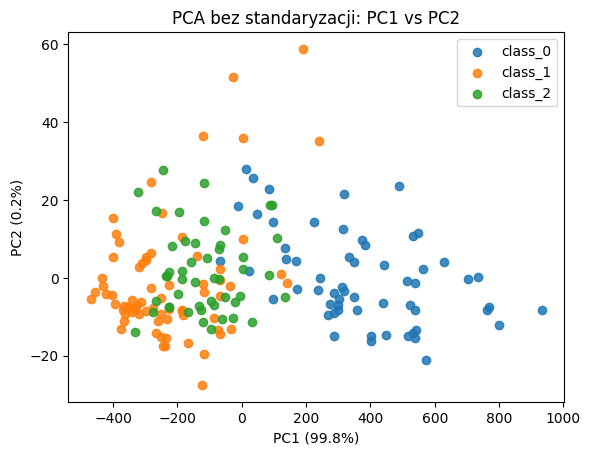

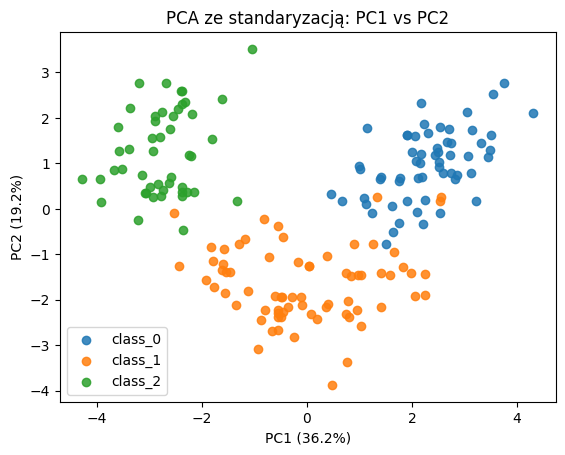


Cecha o największej wariancji w danych surowych (bez standaryzacji):
- proline (wariancja=99166.72)

Cecha o największym |loading| w PC1 (bez standaryzacji):
- proline (loading_PC1=0.9998)

Wniosek: Bez standaryzacji PCA faworyzuje cechy o dużej skali/wariancji.


In [14]:
#Zad 4
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
class_names = wine.target_names

# 4.1
pca_raw = PCA(n_components=2)
X_raw_2d = pca_raw.fit_transform(X)
evr_raw = pca_raw.explained_variance_ratio_ * 100

# 4.2
X_std = StandardScaler().fit_transform(X)
pca_std = PCA(n_components=2)
X_std_2d = pca_std.fit_transform(X_std)
evr_std = pca_std.explained_variance_ratio_ * 100

print("Porównanie wyjaśnionej wariancji (PC1, PC2):")
print(f"Bez standaryzacji: PC1={evr_raw[0]:.1f}%, PC2={evr_raw[1]:.1f}%, suma={evr_raw.sum():.1f}%")
print(f"Ze standaryzacją:  PC1={evr_std[0]:.1f}%, PC2={evr_std[1]:.1f}%, suma={evr_std.sum():.1f}%")

plt.figure()
for cls in np.unique(y):
    m = (y == cls)
    plt.scatter(X_raw_2d[m, 0], X_raw_2d[m, 1], label=class_names[cls], alpha=0.85)
plt.title("PCA bez standaryzacji: PC1 vs PC2")
plt.xlabel(f"PC1 ({evr_raw[0]:.1f}%)")
plt.ylabel(f"PC2 ({evr_raw[1]:.1f}%)")
plt.legend()
plt.show()

plt.figure()
for cls in np.unique(y):
    m = (y == cls)
    plt.scatter(X_std_2d[m, 0], X_std_2d[m, 1], label=class_names[cls], alpha=0.85)
plt.title("PCA ze standaryzacją: PC1 vs PC2")
plt.xlabel(f"PC1 ({evr_std[0]:.1f}%)")
plt.ylabel(f"PC2 ({evr_std[1]:.1f}%)")
plt.legend()
plt.show()

# 4.3
#Największa wariancja w danych surowych
variances = np.var(X, axis=0, ddof=1)
idx_max_var = int(np.argmax(variances))

print("\nCecha o największej wariancji w danych surowych (bez standaryzacji):")
print(f"- {feature_names[idx_max_var]} (wariancja={variances[idx_max_var]:.2f})")

#Największy |loading| w PC1 bez standaryzacji
load_raw = pca_raw.components_.T  # (13×2)
idx_dom_pc1 = int(np.argmax(np.abs(load_raw[:, 0])))

print("\nCecha o największym |loading| w PC1 (bez standaryzacji):")
print(f"- {feature_names[idx_dom_pc1]} (loading_PC1={load_raw[idx_dom_pc1, 0]:.4f})")

print("\nWniosek: Bez standaryzacji PCA faworyzuje cechy o dużej skali/wariancji.")

PCA bez standaryzacji jest zdominowane przez cechy o największej skali i wariancji, co powoduje, że pierwsza składowa wyjaśnia nieproporcjonalnie dużą część wariancji i projekcja 2D jest mniej reprezentatywna niż po standaryzacji. W analizowanym zbiorze danych dominującą cechą była proline, dlatego standaryzacja jest konieczna, aby wyrównać wpływ wszystkich zmiennych.

In [19]:
#Zad 5
wine = load_wine()
X = wine.data
y = wine.target

# 5.1 podział danych 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

def fit_eval(pipe, label):
    t0 = time.perf_counter()
    pipe.fit(X_train, y_train)
    train_time = (time.perf_counter() - t0) * 1000  # ms

    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return label, acc, train_time

# 5.2
pipe_orig = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

pipe_pca2 = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2)),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

pipe_pca5 = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=5)),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

# 5.3
results = [
    fit_eval(pipe_orig, "Oryginalne dane (13 cech)"),
    fit_eval(pipe_pca2,  "PCA (2 składowe)"),
    fit_eval(pipe_pca5,  "PCA (5 składowych)")
]

print("Porównanie modeli k-NN:")
for label, acc, t_ms in results:
    print(f"- {label:28s} | accuracy={acc:.3f} | train_time={t_ms:.1f} ms")

Porównanie modeli k-NN:
- Oryginalne dane (13 cech)    | accuracy=0.972 | train_time=3.4 ms
- PCA (2 składowe)             | accuracy=0.917 | train_time=8.5 ms
- PCA (5 składowych)           | accuracy=1.000 | train_time=3.7 ms
